In [1]:
from pathlib import Path
import sys

import numpy as onp
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.gridspec import GridSpec
from matplotlib.axes import Axes
_project_root = Path.cwd()
if _project_root.name == "notebooks":
  _project_root = _project_root.parent
if str(_project_root) not in sys.path:
  sys.path.insert(0, str(_project_root))

from examples.per_sym import (
  DomainConfig, _2π,  gaussian, bloch_wave, monatomic_dispersion,
  periodic_potential_from_sites,  nearest_neighbor_vectors, find_origin_site, 
	make_k_mesh, diatomic_dispersion
)
import src.symmetry as sym
from src.lattice_geometry import make_honeycomb_lattice, make_triangular_lattice
from plotting_utils import (
  PlotStyle, apply_matplotlib_style, _clean_axes, complex_to_rgb, save_path, subplots_list,
)

from src.config import get_settings



In [2]:
# ---- config

_S = get_settings()
print(_S.media_dir)

def savefig(fig, name, **kwargs):
  if name is None:
    return None
  return save_path(fig, _S.media_dir / name, dpi=300, facecolor="white", **kwargs)

def clean_axes(ax):
  _clean_axes(ax, grid=True, hide_spines=("top", "right"))
  ax.spines["left"].set_linewidth(1.3)
  ax.spines["bottom"].set_linewidth(1.3)


# Keep text as text in the SVG rather than converting everything to paths.
# mpl.rcParams["svg.fonttype"] = "none"
apply_matplotlib_style(PlotStyle(label_size=13, title_size=15, fig_title_size=18))

/Users/jakeschaefer/Desktop/Research_Stuff/mat_sci/crystals/var/media


In [3]:
# --- lattice + continuous grid
cfg = DomainConfig()
a = cfg.a

# --- discrete ring (periodic BCs): sites n = 0,...,N-1
x = onp.linspace(0, cfg.Lx, cfg.Nx, endpoint=False)
y = onp.linspace(0, cfg.Ly, cfg.Ny, endpoint=False)

X, Y = onp.meshgrid(x, y, indexing="xy")
grid = onp.stack((X, Y), axis=-1)
print(grid.shape)

# ---- energy splitting
E0 = 0.0
dE = 0.8
Emin = E0 - dE / 2
Emax = E0 + dE / 2
# ---- continuous spectrum
E_max = 8
E = onp.linspace(0, E_max, 400)


(800, 800, 2)


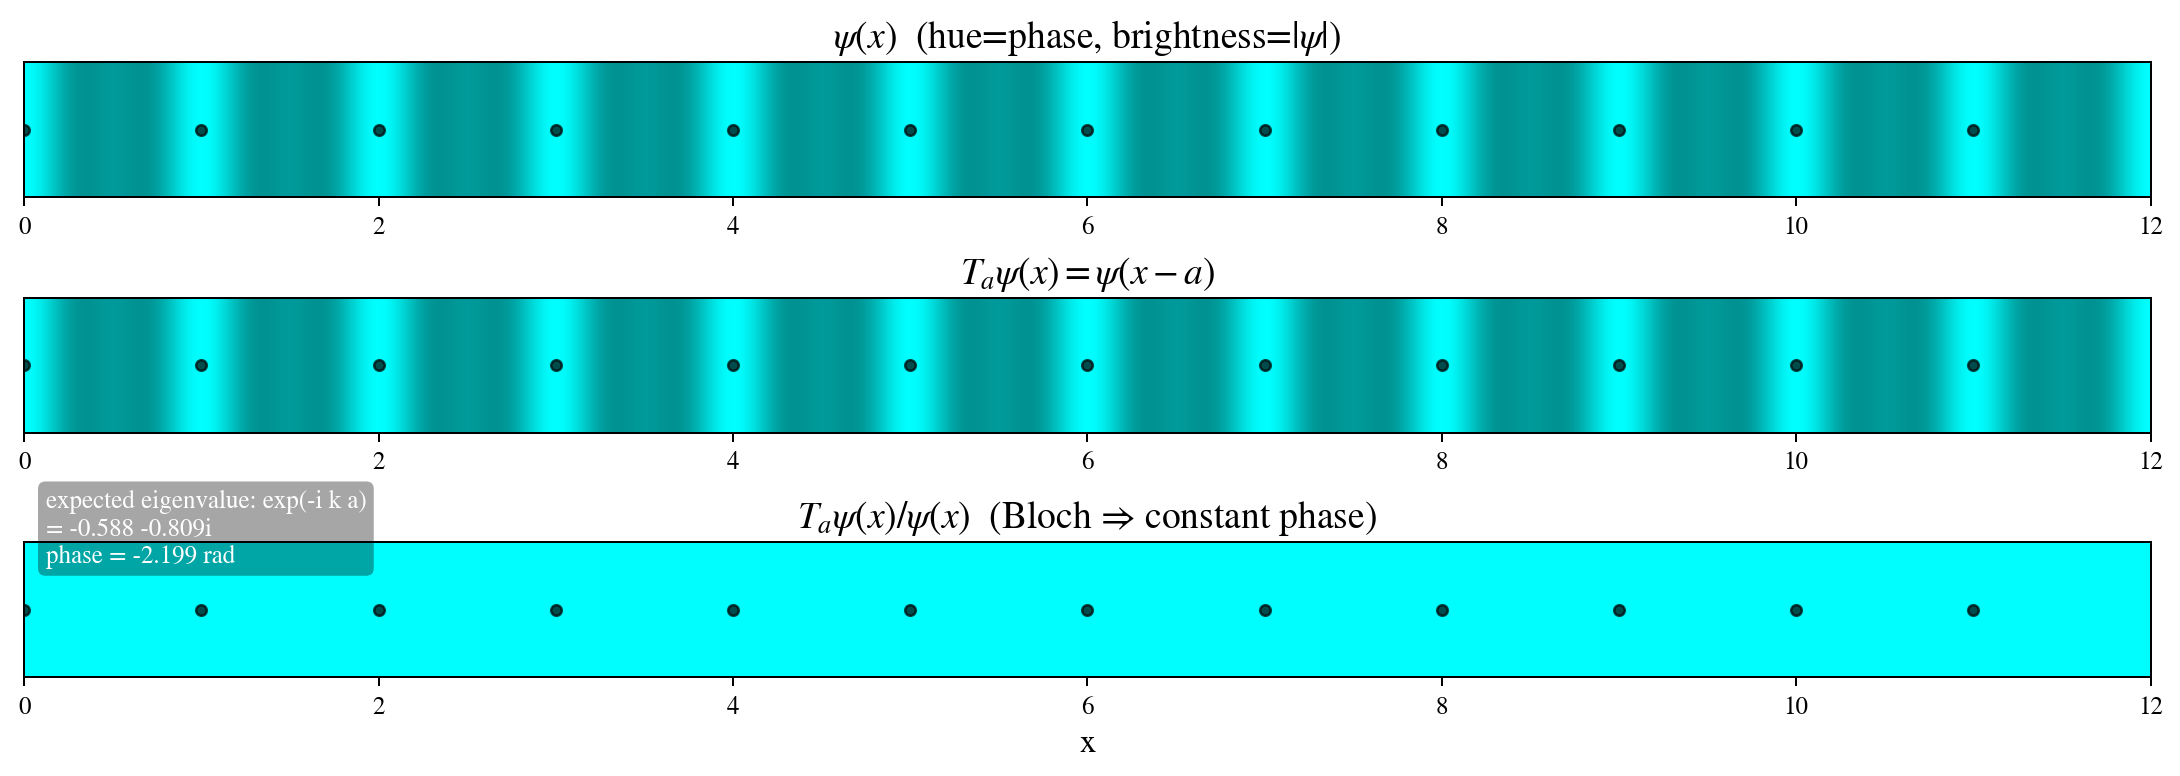

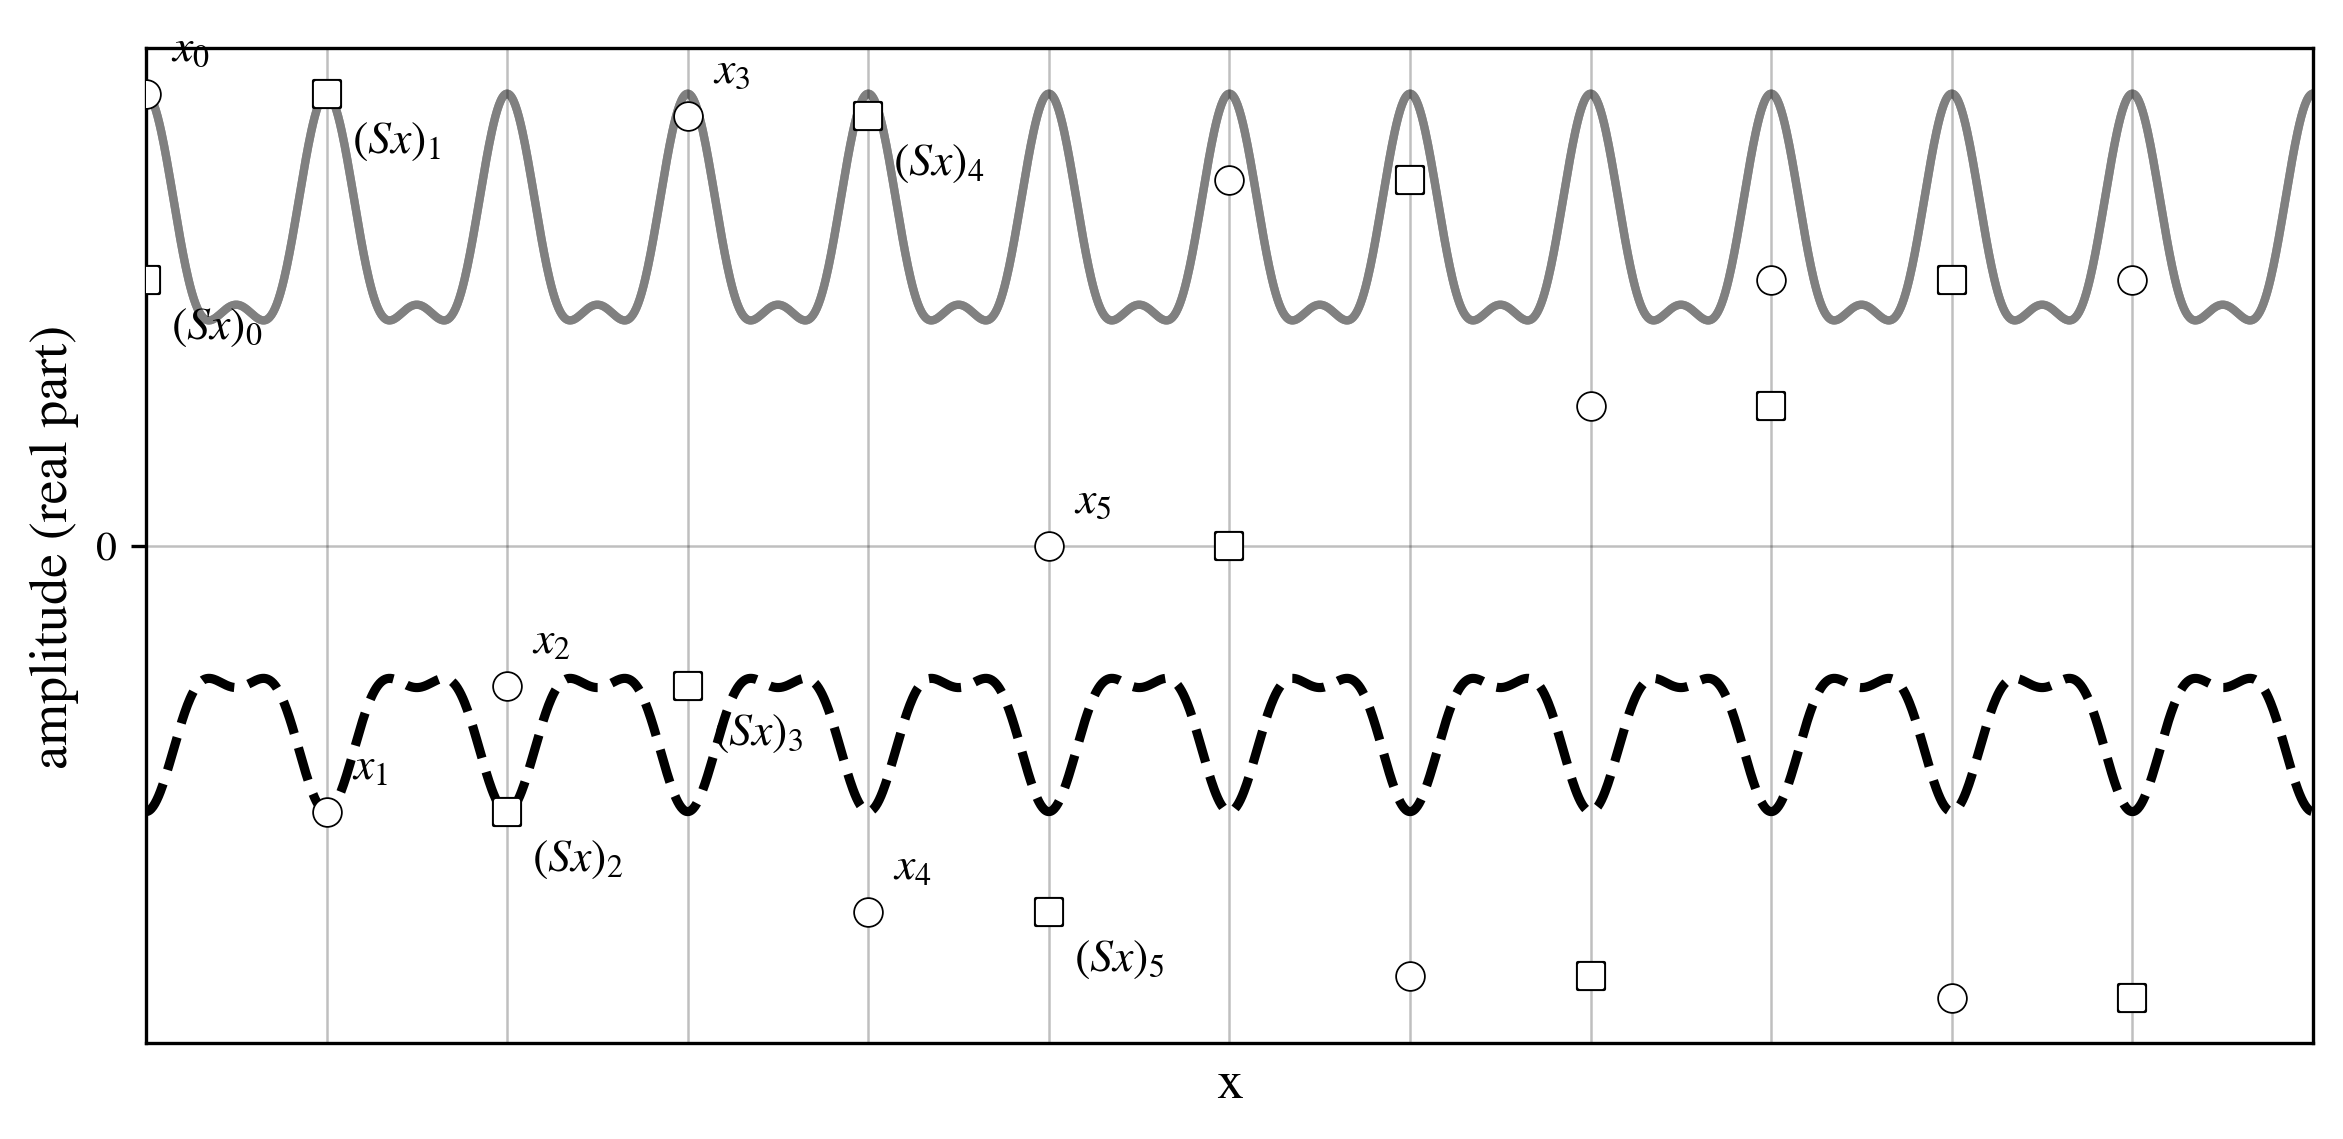

In [6]:
# --- parameters
cfg = DomainConfig(
  a = 1.0,                 # lattice spacing
  Nx_cell=12,             # domain contains Ncells unit cells
  Ny_cell=1,
  res_per_cell=2400//12, # dense continuous sampling for plotting
)
a = cfg.a
x = onp.linspace(0, cfg.Lx, cfg.Nx, endpoint=False)

# Bloch k (pick something not trivial)
k = 0.7 * onp.pi / a

# periodic envelope u(x+a)=u(x)
cvec = onp.array([0.35, 0.15])
M = onp.array([1, 2])
vec = x[:, None] * M
# unfort, we need cvec in the 2nd slot to keep batch dim on axis 0
u = 1.0 + onp.dot(onp.cos(_2π * vec / a), cvec)
psi = u

# psi = bloch_wave(u, k, x)

# translation by one lattice step: (T_a psi)(x) = psi(x-a)
# use periodic wrap on [0, L) to keep the plot clean
# translation by +a: (T_a psi)(x) = psi(x-a) with periodic wrap on [0,L)
x_shift = (x - a) % cfg.Lx # x_mina
vec = x_shift[:, None] * M
u_shift = 1.0 + onp.dot(onp.cos(_2π * vec / a), cvec)

psi_shift = u_shift
# psi_shift = bloch_wave(u_shift, k, x_shift)

# phase-corrected shifted wave: should equal psi(x) exactly (up to numerical noise)
psi_shift_phasefixed = onp.exp(1j * k * a) * psi_shift

# lattice sampling points
sites = onp.arange(0, cfg.Lx, a)
vec = sites[:, None] * M
u_sites = 1.0 + onp.dot(onp.cos(_2π * vec / a), cvec)

psi_sites = bloch_wave(u_sites, k, sites)


def plot(cfg: DomainConfig, psi, psi_shift):
  ratio = psi_shift / (psi + 1e-12)
  expected = onp.exp(-1j * onp.multiply(k, a))
  # --- make RGB strips (1 x Nx image)
  strip_psi = complex_to_rgb(psi)[None, :, :]
  strip_shift = complex_to_rgb(psi_shift)[None, :, :]
  strip_ratio = complex_to_rgb(ratio)[None, :, :]

  fig, ax = subplots_list(3, 1, figsize=(12, 4.2), constrained_layout=True)

  extent = (0, cfg.Lx, 0, cfg.Ly)
  ax[0].imshow(strip_psi, origin="lower", extent=extent, aspect="auto")
  ax[0].set_title(r"$\psi(x)$  (hue=phase, brightness=$|\psi|$)")

  ax[1].imshow(strip_shift, origin="lower", extent=extent, aspect="auto")
  ax[1].set_title(r"$T_a \psi(x)=\psi(x-a)$")

  ax[2].imshow(strip_ratio, origin="lower", extent=extent, aspect="auto")
  ax[2].set_title(r"$T_a\psi(x) / \psi(x)$  (Bloch ⇒ constant phase)")

  # overlay lattice sites as sample points
  sites = onp.arange(0, cfg.Lx, a)
  for a_i in ax:
    a_i.scatter(sites, 0.5*onp.ones_like(sites), s=18, c="k", alpha=0.7)
    a_i.set_yticks([])
    a_i.set_xlim(0, cfg.Lx)

  phi = onp.angle(expected)
  ax[2].text(
    0.01*cfg.Lx, 0.85,
    f"expected eigenvalue: exp(-i k a)\n= {expected.real:+.3f} {expected.imag:+.3f}i\nphase = {phi:+.3f} rad",
    color="w", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor=(0,0,0,0.35), edgecolor="none")
  )

  ax[2].set_xlabel("x")
  plt.show()

  # ---- plot (real part as "amplitude")
  fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
  ax.plot(x, onp.real(psi), linewidth=2, label=r"$\Re\,\psi(x)$", color="grey")
  ax.plot(x, onp.real(psi_shift), linewidth=2, alpha=0.8, label=r"$\Re\,(T_a\psi)(x)=\Re\,\psi(x-a)$", color="gray")
  ax.plot(x, onp.real(psi_shift_phasefixed), "--", linewidth=2.2, label=r"$\Re\,(e^{ika}T_a\psi)(x)$", color="k") # (should coincide with $\Re\,\psi(x)$)

  # mark lattice sites
  for s in sites:
    ax.axvline(s, linewidth=0.6, alpha=0.25, color="k")

  # # show sampled values at lattice sites
  # original samples
  y = onp.real(psi_sites)
  ax.scatter(sites, y, s=40, zorder=5, label=r"$x_n$", color="k")
  ax.scatter(sites, y, s=30, zorder=5, color="white")

  # shifted samples, e.g. (Sx)_n = x_{n-1}
  sites_s = sites
  y_s = onp.roll(y, 1)  # illustrative discrete shift on samples

  ax.scatter(sites_s, y_s, s=40, marker="s", zorder=5, label=r"$(Sx)_n$", color="k")
  ax.scatter(sites_s, y_s, s=30, marker="s", zorder=5, color="white")

  # label a few n’s
  for n in range(6):
    xi, yi = sites[n], y[n]
    ax.annotate(rf"$x_{{{n}}}$", (xi, yi), xytext=(6, 8),
                textcoords="offset points", fontsize=11)

    xi2, yi2 = sites_s[n], y_s[n]
    ax.annotate(rf"$(Sx)_{{{n}}}$", (xi2, yi2), xytext=(6, -14),
                textcoords="offset points", fontsize=11)


  # ax.set(title=r"Shift/translation: for Bloch waves, $e^{ika}T_a\psi=\psi$")
  ax.set(
    xlabel="x",
    ylabel="amplitude (real part)",
    xlim=(0, cfg.Lx),
    xticks=[],
    yticks=[0],
  )
  ax.axhline(0, xmin=0, linewidth=0.6, alpha=0.25, color="k")
  # ax.legend(loc="upper right")
  plt.tight_layout()
  plt.show()



plot(cfg, psi, psi_shift)

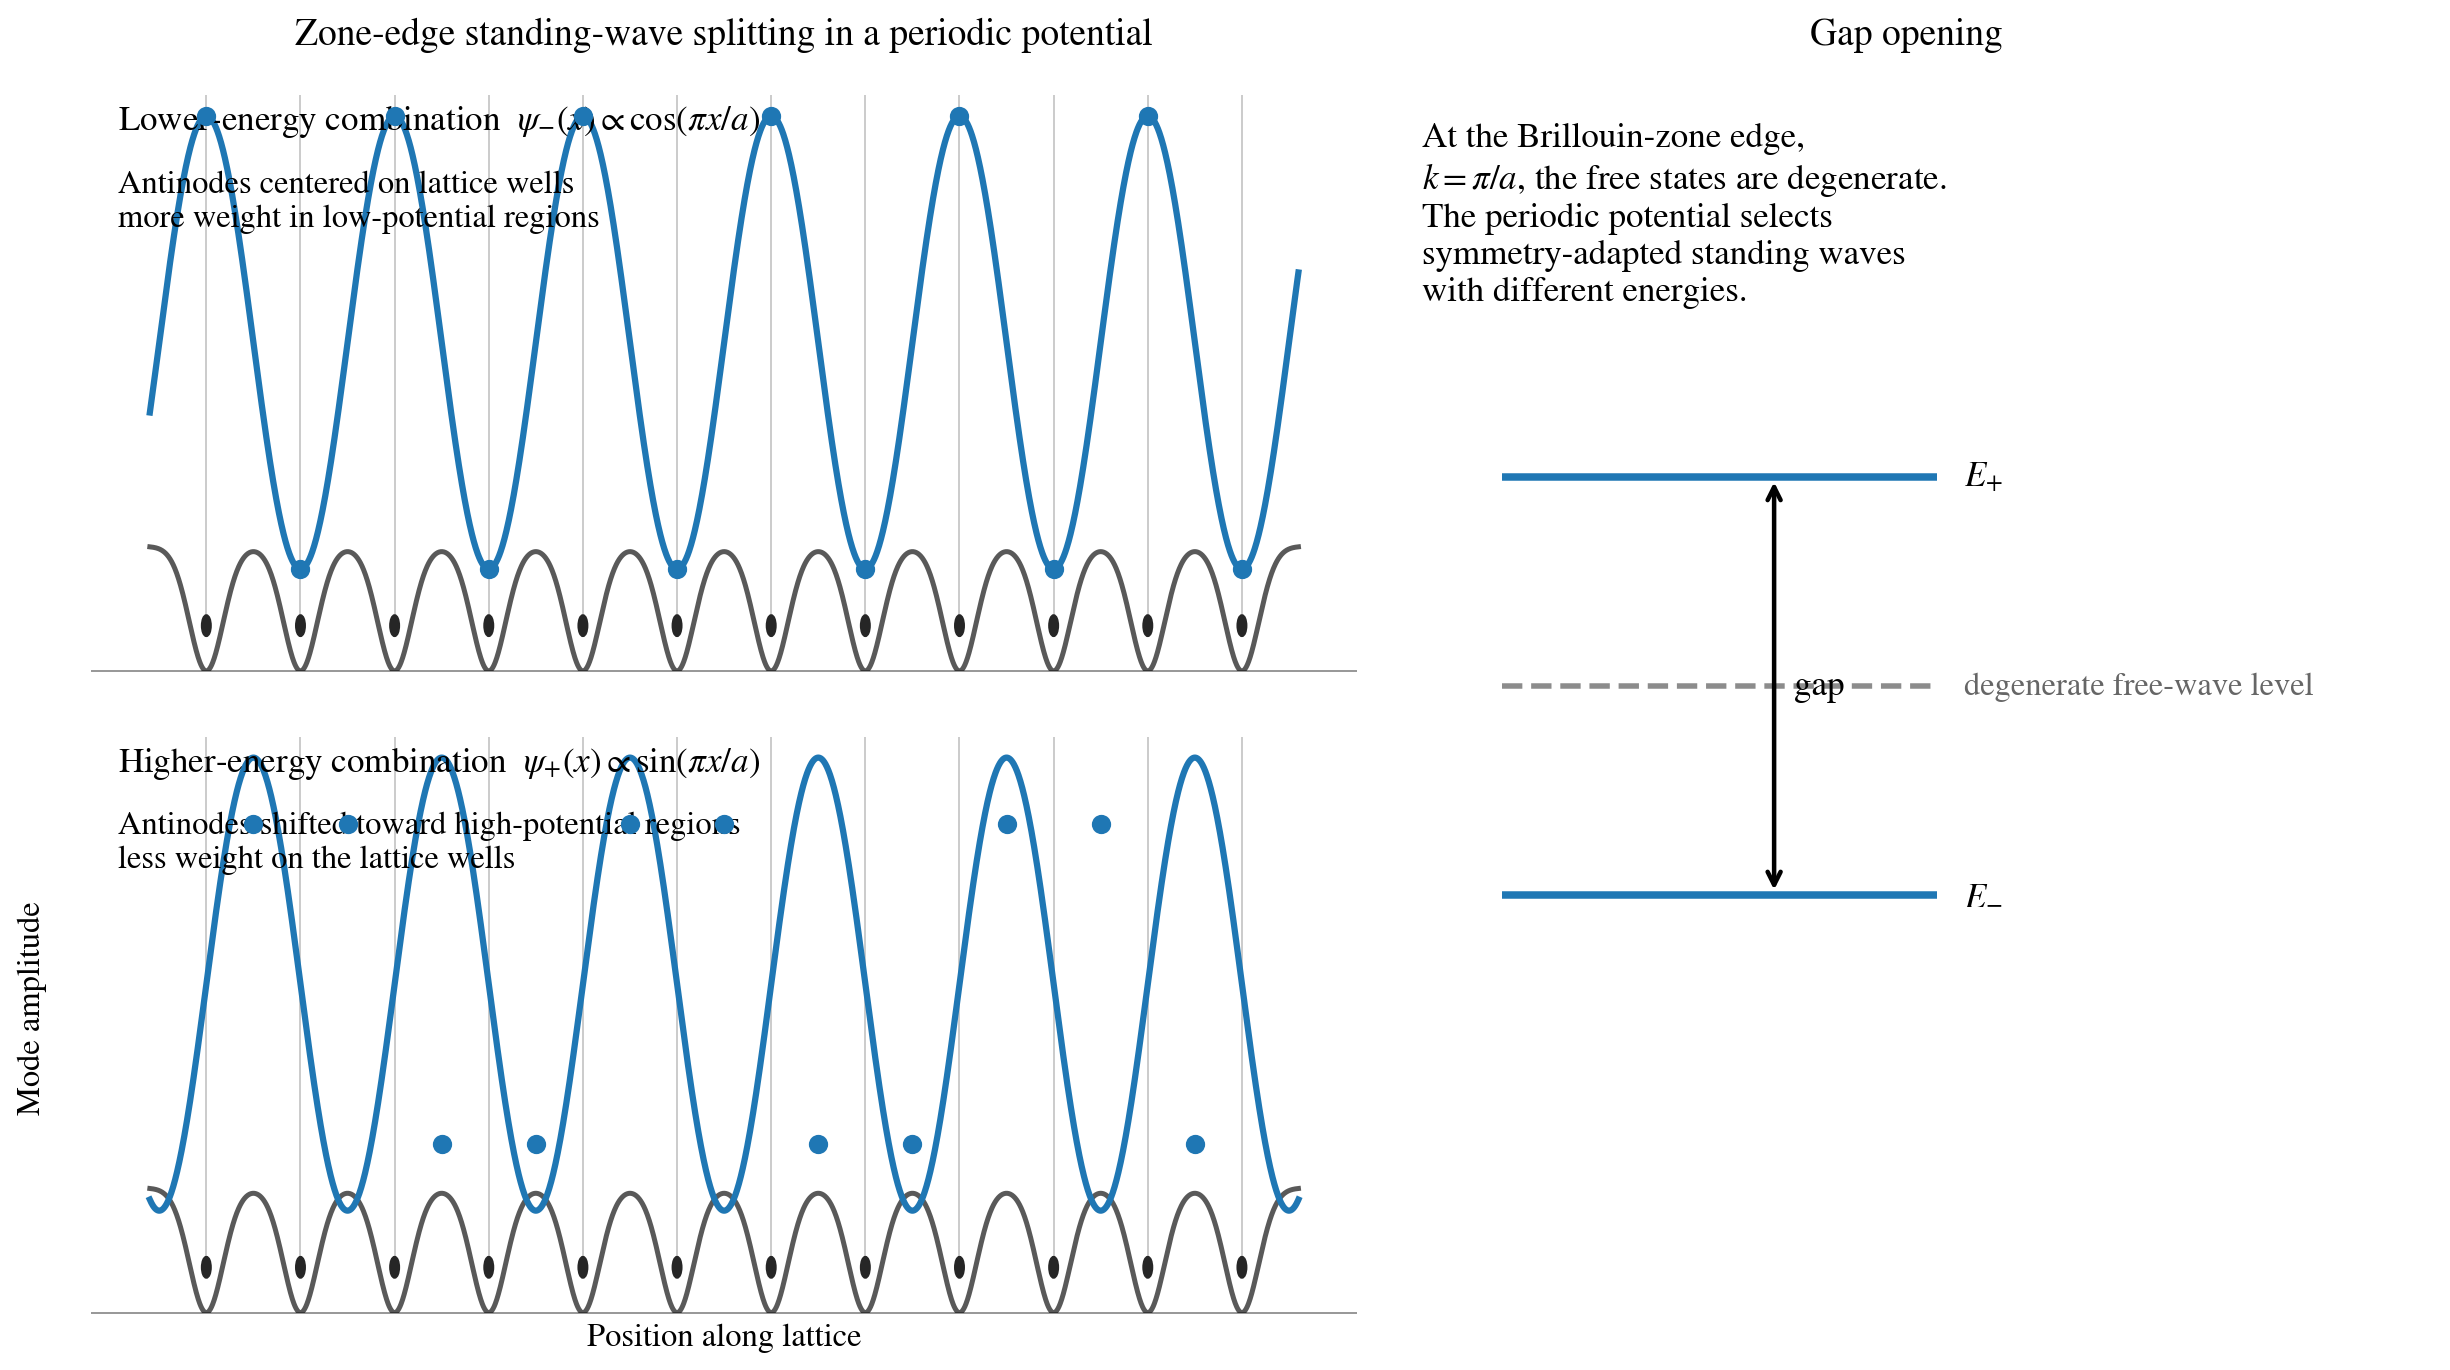

In [15]:

a = cfg.a
sigma = 0.18

# Lattice sites
x_sites = onp.arange(cfg.Nx_cell) * a
x_min = -0.6 * a

x_max = ((cfg.Nx_cell - 1) + 0.6) * a

x = onp.linspace(x_min, x_max, 3000)


# Zone-boundary standing waves: cos(pi x / a) and sin(pi x / a)
# Shift sin by a/2 so its maxima sit between lattice sites.
psi_lo = onp.cos(_2π * x / (2 * a))
psi_hi = onp.sin(_2π * x / (2 * a))

# Periodic potential: wells at lattice sites
V = onp.zeros_like(x)
for xs in x_sites:
  V -= 1.0 * gaussian(x, xs, sigma)

# Normalize / rescale potential for plotting
V = V / onp.max(onp.abs(V))
V_plot = 0.55 * V - 0.9


def make_zone_edge_splitting_figure():
  # Set up figure
  fig = plt.figure(figsize=(13.5, 7.5), constrained_layout=True)
  gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1.0], height_ratios=[1, 1])

  ax1 = fig.add_subplot(gs[0, 0])
  ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
  axE = fig.add_subplot(gs[:, 1])

  # ---------- Top panel: low-energy standing wave ----------
  ax1.plot(x, V_plot, lw=2.0, color="0.35")
  ax1.plot(x, psi_lo, lw=2.5)

  # Lattice sites
  for xs in x_sites:
    ax1.axvline(xs, ymin=0.06, ymax=0.94, lw=0.8, color="0.8", zorder=0)
    ax1.add_patch(Circle((xs, -1.25), 0.045, fill=True, color="0.15"))

  # Mark maxima near low-potential sites
  site_vals = onp.cos(onp.pi * x_sites / a)
  ax1.scatter(x_sites, site_vals, s=45, zorder=5)

  ax1.text(0.02, 0.93,
    r"Lower-energy combination  $\psi_{-}(x)\propto \cos(\pi x/a)$",
    transform=ax1.transAxes, ha="left", va="top", fontsize=14)
  ax1.text(0.02, 0.82,
    "Antinodes centered on lattice wells\nmore weight in low-potential regions",
    transform=ax1.transAxes, ha="left", va="top")
  ax1.set(ylim=(-1.45, 1.25), xticks=[], yticks=[], title="Zone-edge standing-wave splitting in a periodic potential")

  # ---------- Bottom panel: high-energy standing wave ----------
  ax2.plot(x, V_plot, lw=2.0, color="0.35")
  ax2.plot(x, psi_hi, lw=2.5)

  # Lattice sites
  for xs in x_sites:
    ax2.axvline(xs, ymin=0.06, ymax=0.94, lw=0.8, color="0.8", zorder=0)
    ax2.add_patch(Circle((xs, -1.25), 0.045, fill=True, color="0.15"))

  # Mark maxima between lattice sites
  x_mid = x_sites[:-1] + 0.5 * a
  mid_vals = onp.sin(onp.pi * x_mid / (2 * a))
  ax2.scatter(x_mid, mid_vals, s=45, zorder=5)

  ax2.text(
    0.02, 0.93,
    r"Higher-energy combination  $\psi_{+}(x)\propto \sin(\pi x/a)$",
    transform=ax2.transAxes,
    ha="left", va="top",
    fontsize=14
  )
  ax2.text(
    0.02, 0.82,
    "Antinodes shifted toward high-potential regions\nless weight on the lattice wells",
    transform=ax2.transAxes,
    ha="left", va="top"
  )
  ax2.set(ylim=(-1.45, 1.25), yticks=[], xlabel="Position along lattice")
  ax2.set_ylabel(ylabel="Mode amplitude", labelpad=18)

  # ---------- Right panel: energy splitting schematic ----------
  
  axE.hlines(E0, 0.18, 0.82, lw=2.2, linestyles="dashed", color="0.55")
  axE.hlines(Emin, 0.18, 0.82, lw=3.0)
  axE.hlines(Emax, 0.18, 0.82, lw=3.0)

  axE.text(0.86, E0, r"degenerate free-wave level", va="center", fontsize=13, color="0.4")
  axE.text(0.86, Emin, r"$E_{-}$", va="center", fontsize=14)
  axE.text(0.86, Emax, r"$E_{+}$", va="center", fontsize=14)

  axE.annotate(
    "",
    xy=(0.58, Emax),
    xytext=(0.58, Emin),
    arrowprops=dict(arrowstyle="<->", lw=1.8)
  )
  axE.text(0.61, 0.5 * (Emin + Emax), "gap", va="center", fontsize=14)

  axE.text(
    0.04, 0.95,
    "At the Brillouin-zone edge,\n"
    r"$k=\pi/a$, the free states are degenerate." "\n"
    "The periodic potential selects\n"
    "symmetry-adapted standing waves\n"
    "with different energies.",
    transform=axE.transAxes,
    ha="left", va="top",
    fontsize=14
  )

  axE.set(xlim=(0, 1.55), ylim=(-1.2, 1.2), xticks=[], yticks=[], title="Gap opening")
  for spine in axE.spines.values():
    spine.set_visible(False)

  # ---------- Cosmetic cleanup ----------
  for ax in (ax1, ax2):
    for spine in ["top", "right", "left"]:
      ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_alpha(0.4)

  return fig


if __name__ == "__main__":
  fig = make_zone_edge_splitting_figure()
  # savefig(fig, "zone_edge_standing_wave_splitting.png", bbox_inches="tight")
  plt.show()

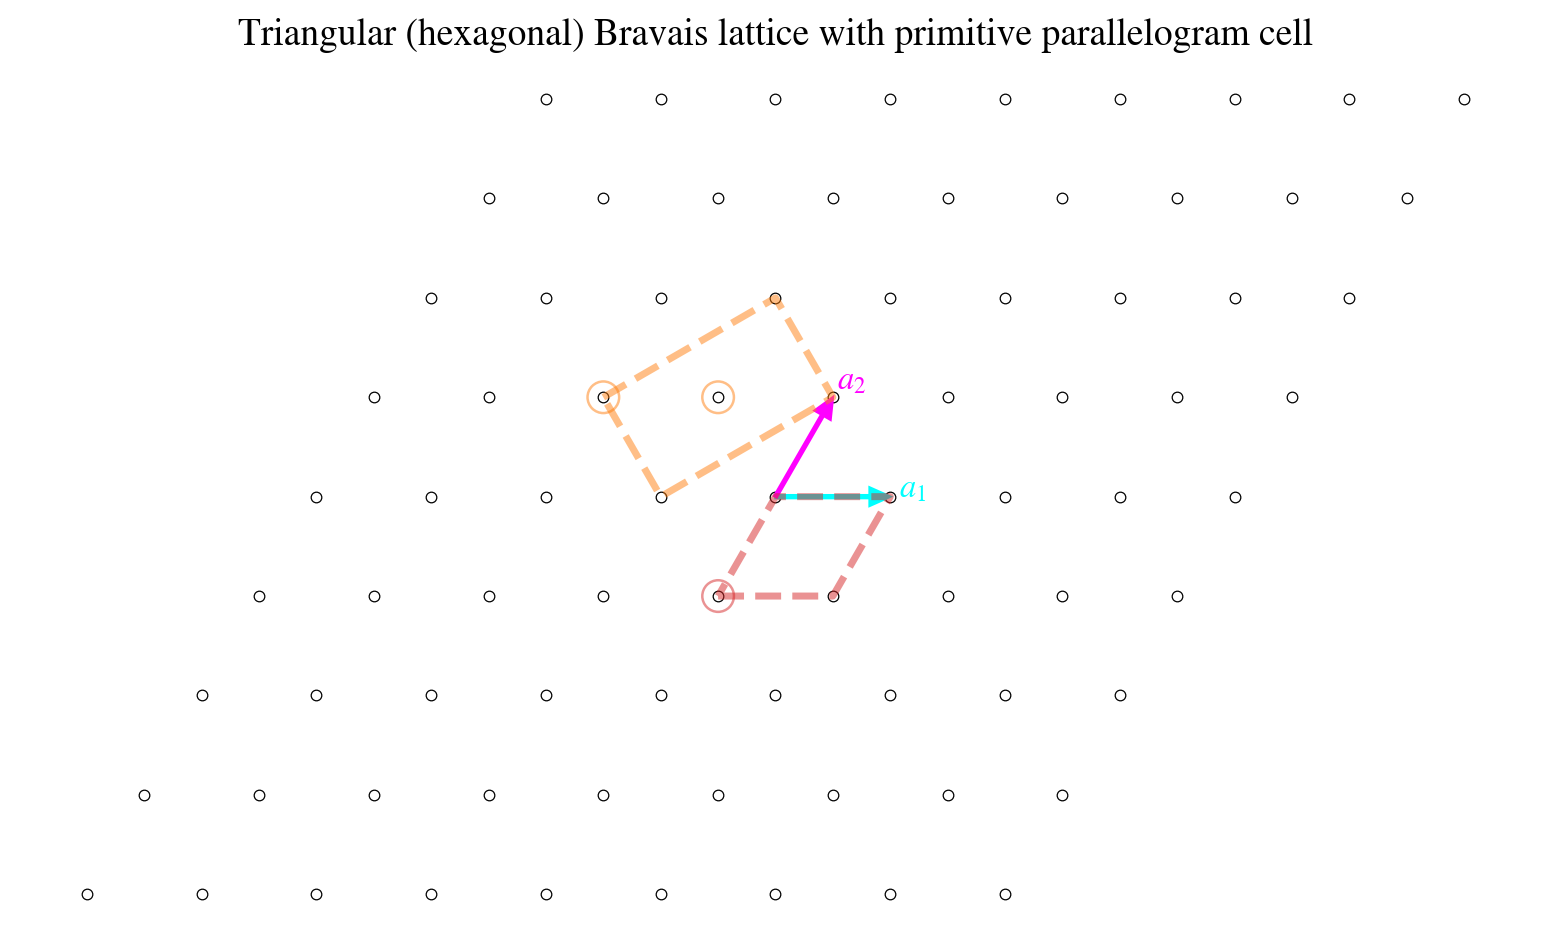

In [46]:


def plot_honeycomb_and_potential(
  n1=4,
  n2=4,
  a=1.0,
  sigma=0.20,
  depth=1.0,
  grid_pts=500,
  cmap="viridis",
):
  ptsA, ptsB, A, bA, bB = make_honeycomb_lattice(n1, n2, a=a)
  pts = onp.vstack([ptsA, ptsB])

  xmin = pts[:, 0].min() - 1.0 * a
  xmax = pts[:, 0].max() + 1.0 * a
  ymin = pts[:, 1].min() - 1.0 * a
  ymax = pts[:, 1].max() + 1.0 * a

  x = onp.linspace(xmin, xmax, grid_pts)
  y = onp.linspace(ymin, ymax, grid_pts)
  X, Y = onp.meshgrid(x, y)

  V = periodic_potential_from_sites(X, Y, pts, sigma=sigma, depth=depth)

  fig, ax = plt.subplots(figsize=(8.5, 8), constrained_layout=True)

  im = ax.imshow(
    V,
    extent=(xmin, xmax, ymin, ymax),
    origin="lower",
    cmap=cmap,
    aspect="equal",
  )

  ax.scatter(ptsA[:, 0], ptsA[:, 1], s=18, c="red", edgecolors="black", linewidths=0.5, label="A")
  ax.scatter(ptsB[:, 0], ptsB[:, 1], s=18, c="white", edgecolors="black", linewidths=0.5, label="B")

  ax.set(
    title="Honeycomb lattice = triangular Bravais lattice + 2-point basis",
    xlabel="x",
    ylabel="y",
    aspect="equal",
  )
  ax.legend(loc="upper right")

  cbar = fig.colorbar(im, ax=ax, shrink=0.85)
  cbar.set_label(r"$V(x,y)$")

  return fig, ax


def triangular_unit_cell(unit_cell: str, A):
  a1, a2 = A[:, 0], A[:, 1]

  if unit_cell == "parallelogram":
    cell = onp.array([
      [0.0, 0.0],
      a1,
      a1 + a2,
      a2,
    ])
    motif = onp.array([[0.0, 0.0]])
  elif unit_cell == "rectangle":
    # A rectangular 2-site conventional cell for the same triangular lattice.
    b1 = a1 + a2
    b2 = a1 - a2
    cell = onp.array([
      [0.0, 0.0],
      b1,
      b1 + b2,
      b2,
    ])
    motif = onp.array([
      [0.0, 0.0],
      a1,
    ])
  else:
    raise ValueError("unit_cell must be 'parallelogram' or 'rectangle'")

  return cell, motif


def plot_triangular_lattice_and_potential(
  n1=4,
  n2=4,
  a=1.0,
  sigma=0.23,
  depth=1.0,
  grid_pts=500,
  show_neighbors=True,
  show_primitive_vectors=True,
  cmap="viridis",
  plot_potential: bool=False,
  unit_cell: str | None = None,
  xlim=None,
  ylim=None
):
  r""" """
  pts, A = make_triangular_lattice(n1, n2, a=a)
  a1, a2 = A[:, 0], A[:, 1]

  # Plot window
  xmin = pts[:, 0].min() - 0.8 * a
  xmax = pts[:, 0].max() + 0.8 * a
  ymin = pts[:, 1].min() - 0.8 * a
  ymax = pts[:, 1].max() + 0.8 * a

  fig, ax = plt.subplots(figsize=(8.5, 8), constrained_layout=True)
  if plot_potential:
    x = onp.linspace(xmin, xmax, grid_pts)
    y = onp.linspace(ymin, ymax, grid_pts)
    X, Y = onp.meshgrid(x, y)
    V = periodic_potential_from_sites(X, Y, pts, sigma=sigma, depth=depth)
    
    im = ax.imshow(
      V,
      extent=(xmin, xmax, ymin, ymax),
      origin="lower",
      cmap=cmap,
      aspect="equal",
    )

    cbar = fig.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label(r"$V(x,y)$")

  # Lattice sites
  ax.scatter(pts[:, 0], pts[:, 1], s=18, c="white", edgecolors="black", linewidths=0.5, zorder=3)

  origin_idx = find_origin_site(pts)
  r0 = pts[origin_idx]

  # Highlight one site
  # ax.scatter([r0[0]], [r0[1]], s=55, c="red", zorder=4)

  if show_neighbors:
    nn = nearest_neighbor_vectors(a1, a2)
    for d in nn:
      r = r0 + d
      ax.plot([r0[0], r[0]], [r0[1], r[1]], "--",lw=2.0, color="black", alpha=0.8, zorder=2)
      ax.scatter([r[0]], [r[1]], s=45, c="red", edgecolors="black", linewidths=0.5, zorder=4)

  if show_primitive_vectors:
    ax.arrow(
      r0[0], r0[1], a1[0], a1[1],
      width=0.025 * a, head_width=0.16 * a, head_length=0.18 * a,
      length_includes_head=True, color="cyan", zorder=5
    )
    ax.arrow(
      r0[0], r0[1], a2[0], a2[1],
      width=0.025 * a, head_width=0.16 * a, head_length=0.18 * a,
      length_includes_head=True, color="magenta", zorder=5
    )
    ax.text(*(r0 + 1.08 * a1), r"$a_1$", color="cyan", fontsize=13)
    ax.text(*(r0 + 1.08 * a2), r"$a_2$", color="magenta", fontsize=13)

  if unit_cell is not None:
    cell, motif = triangular_unit_cell(unit_cell, A)
    cell = cell + r0 - a2
    motif = motif + r0 - a2
    cell_loop = onp.vstack([cell, cell[:1]])
    ax.plot(cell_loop[:, 0], cell_loop[:, 1], '--', color="tab:red", alpha=0.5, lw=2.8, zorder=6)
    ax.scatter(
      motif[:, 0],
      motif[:, 1],
      s=160,
      facecolors="none",
      edgecolors="tab:red",
      alpha=0.5,
      linewidths=1.0,
      zorder=7,
    )

    cell, motif = triangular_unit_cell("rectangle", A)
    cell = cell + (r0 - 2 * a1 + a2)
    motif = motif + (r0 - 2 * a1 + a2)
    cell_loop = onp.vstack([cell, cell[:1]])
    ax.plot(cell_loop[:, 0], cell_loop[:, 1], '--',color="tab:orange", alpha=0.5, lw=2.8, zorder=6)
    ax.scatter(
      motif[:, 0],
      motif[:, 1],
      s=160,
      facecolors="none",
      edgecolors="tab:orange",
      alpha=0.5,
      linewidths=1.0,
      zorder=7,
    )

  title = "Triangular (hexagonal) Bravais lattice"
  if unit_cell == "parallelogram":
    title += " with primitive parallelogram cell"
  elif unit_cell == "rectangle":
    title += " with 2-site rectangular cell"

  ax.set(title=title, 
          xlabel="x",ylabel="y", xlim=xlim, ylim=ylim, xticks=[], yticks=[], 
          aspect="equal")

  plt.axis('off')


  # cbar = fig.colorbar(im, ax=ax, shrink=0.85)
  # cbar.set_label(r"$V(x,y)$")
  return fig, ax


if __name__ == "__main__":
  plot_triangular_lattice_and_potential(
    n1=4,
    n2=4,
    a=1.0,
    sigma=0.23,
    depth=0.1,
    grid_pts=1_000,
    show_neighbors=False,
    show_primitive_vectors=True,
    unit_cell="parallelogram",
    # cmap="magma_r",
    cmap="gray_r",

  )
  # savefig(fig, "triangular_lattice_potential", bbox_inches="tight")
  plt.show()

  # plot_triangular_lattice_and_potential(
  #   n1=4,
  #   n2=4,
  #   a=1.0,
  #   sigma=0.23,
  #   depth=1.0,
  #   grid_pts=1_000,
  #   show_neighbors=True,
  #   show_primitive_vectors=True,
  #   unit_cell="rectangle",
  #   # cmap="magma_r",
  #   cmap="gray_r",
  # )

  # fig, _ = plot_honeycomb_and_potential(cmap="magma_r")
  # fig.savefig("honeycomb_potential", dpi=300, bbox_inches="tight")
  plt.show()

In [5]:
# ----------------------------
# Global presentation styling
# ----------------------------
apply_matplotlib_style(PlotStyle(
  figure_dpi=180,
  label_size=18,
  title_size=22,
  tick_size=15,
  legend_size=15,
  fig_title_size=18,
  font_family="serif",
  lw_main=3.0,
))
plt.rcParams.update({
  "figure.figsize": (10, 6),
  "axes.spines.top": False,
  "axes.spines.right": False,
  "savefig.bbox": "tight",
})


def style_band_axes(ax, a=1.0):
  kmin = -onp.pi / a
  kmax = onp.pi / a

  ax.set_xlim(kmin, kmax)
  ax.set_xticks([-onp.pi / a, 0.0, onp.pi / a])
  ax.set_xticklabels([r"$-\pi/a$", r"$0$", r"$\pi/a$"], fontsize=13)

  ax.set_xlabel(r"$k$", fontsize=15)
  ax.set_ylabel(r"$\omega$", fontsize=15)

  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)

  ax.axvline(-onp.pi / a, linestyle="--", linewidth=1.0, alpha=0.35)
  ax.axvline(0.0, linestyle="--", linewidth=1.0, alpha=0.35)
  ax.axvline(onp.pi / a, linestyle="--", linewidth=1.0, alpha=0.35)

  ax.tick_params(axis="both", labelsize=12)
  ax.grid(False)


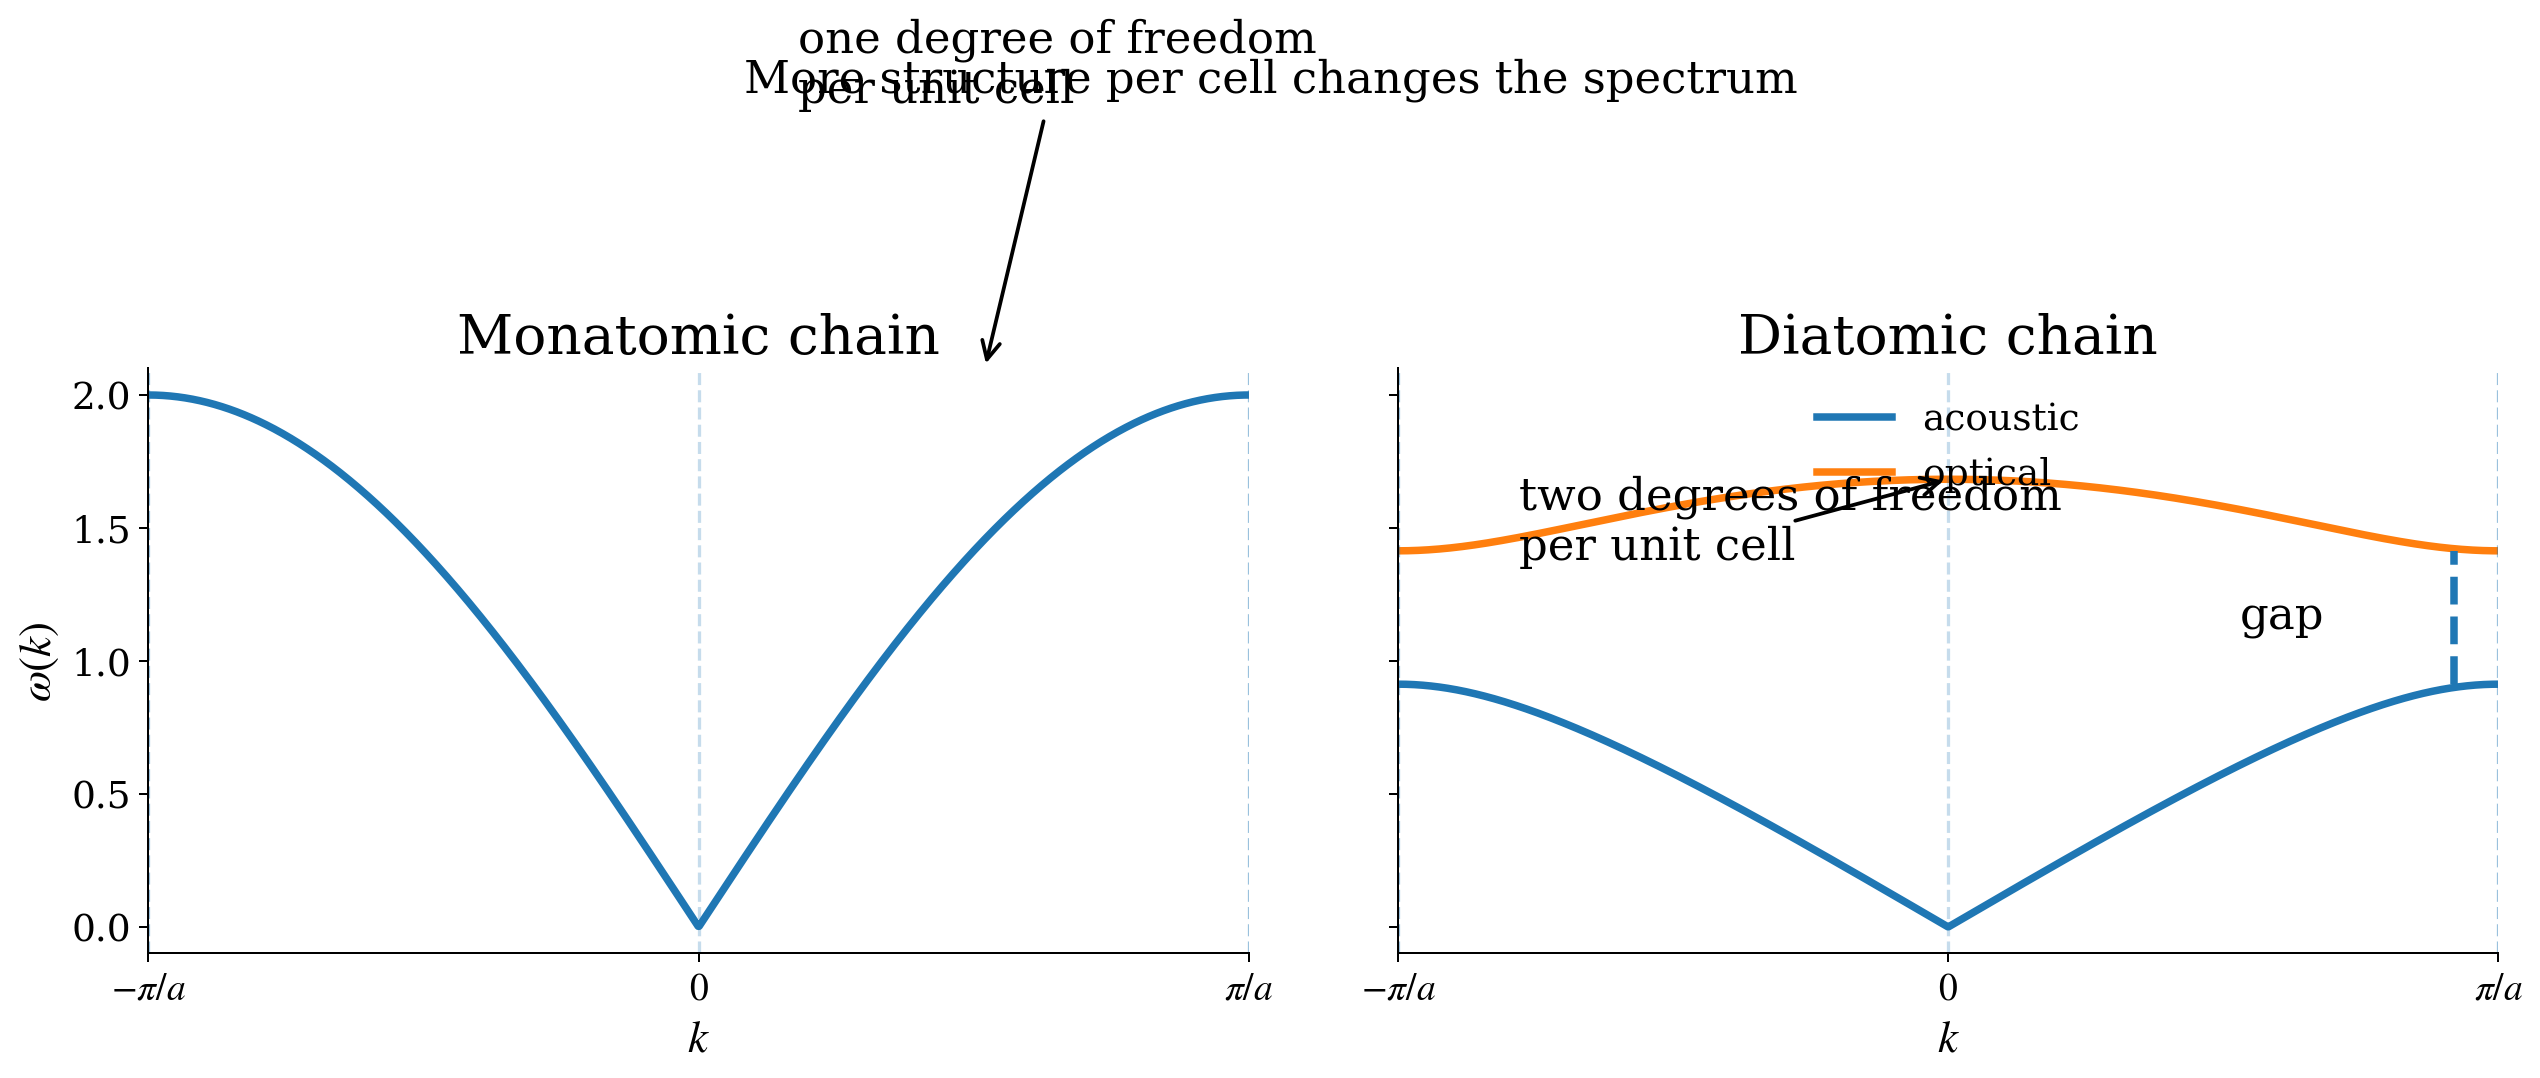

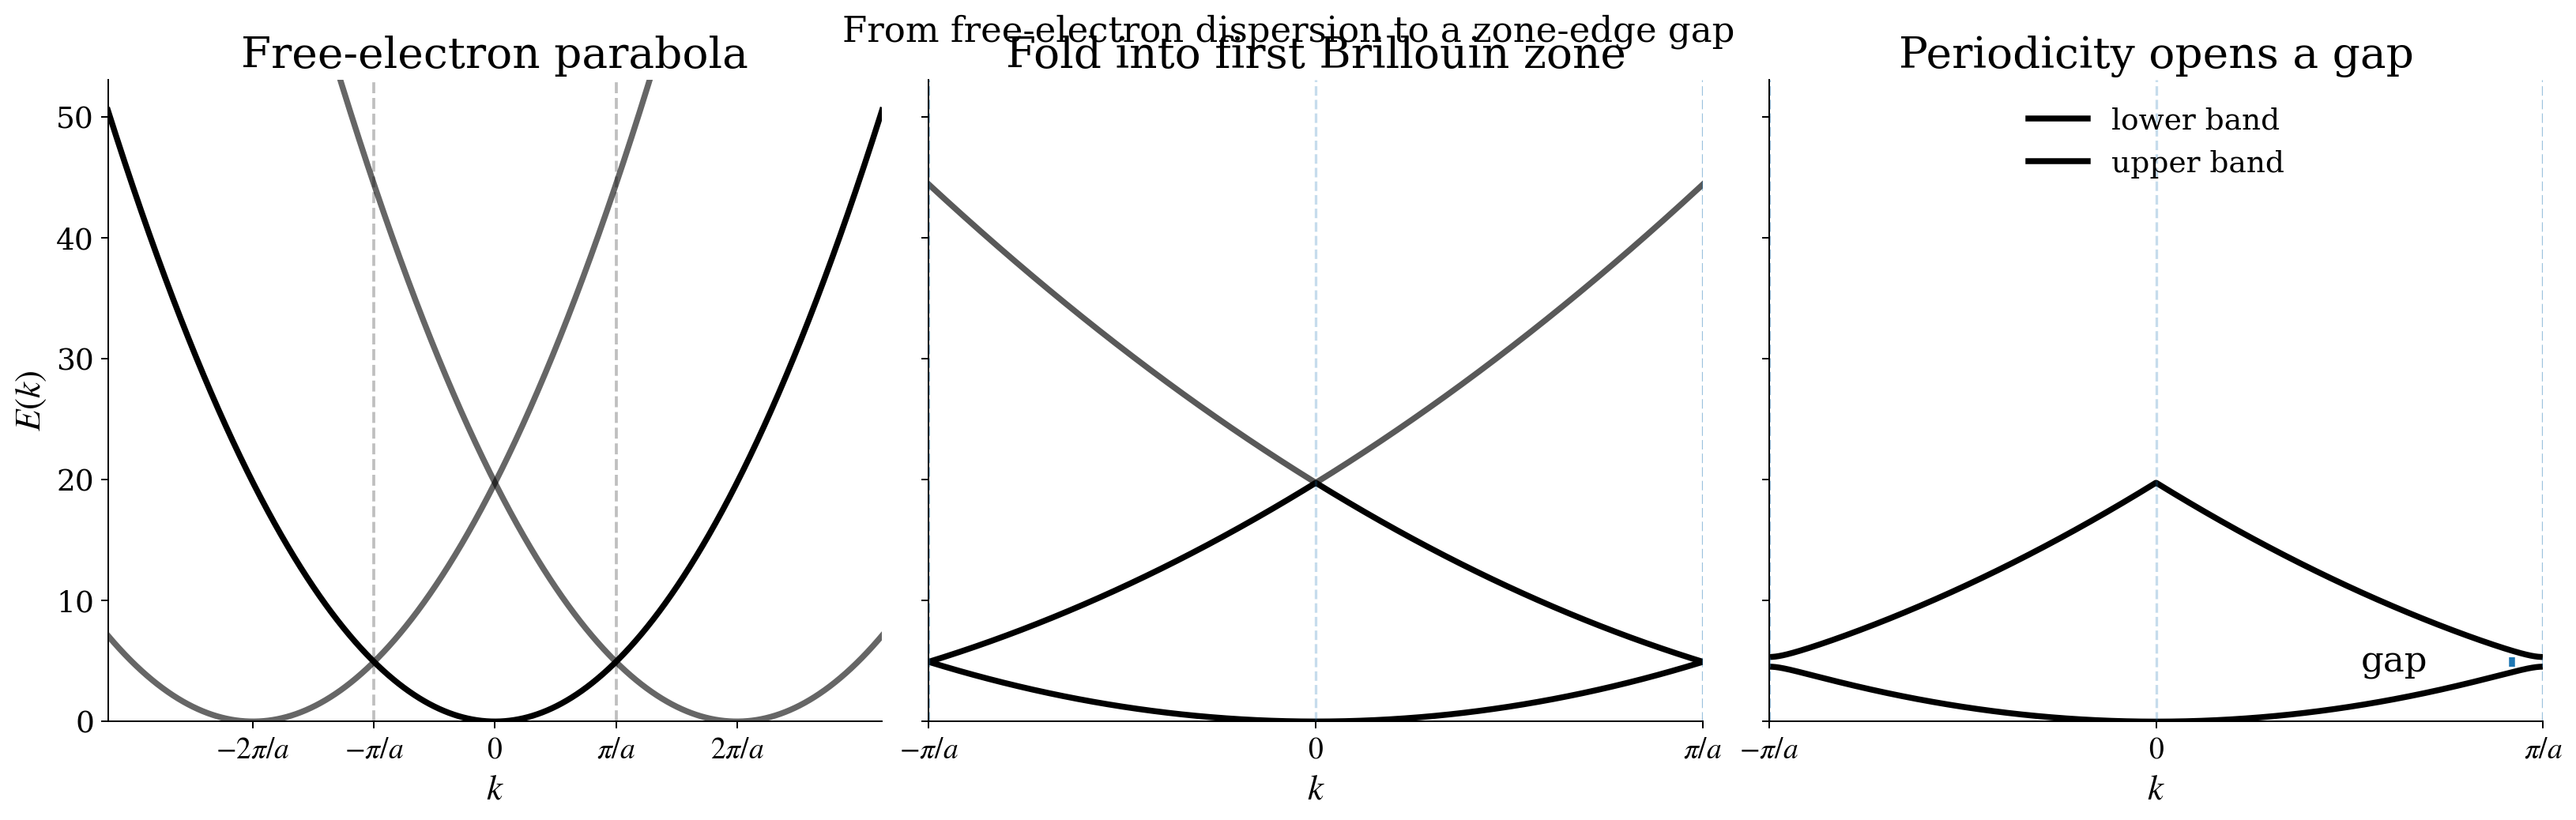

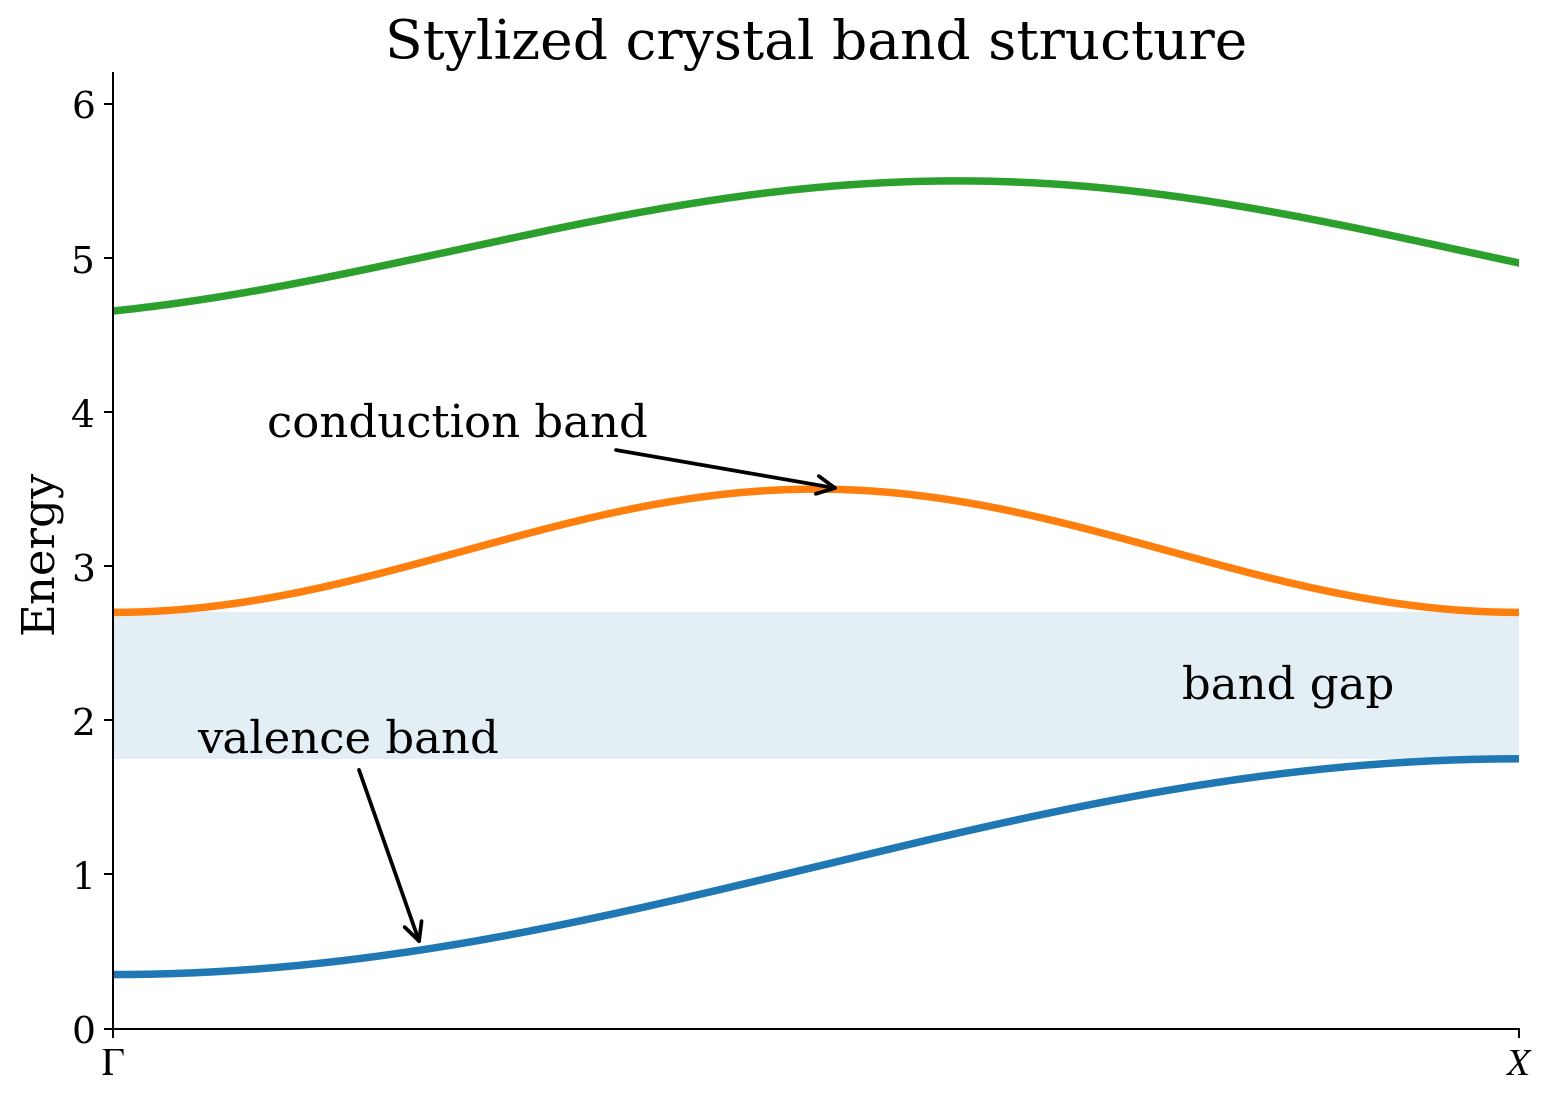

In [6]:
from examples.lattice_plots import (
  plot_folded_parabola_gap,
  plot_mono_vs_diatomic,
  plot_simple_band_structure,
)

fig = plot_mono_vs_diatomic(a=1.0, K=1.0, M_mono=1.0, m1=1.0, m2=2.4)
plt.show()

fig = plot_folded_parabola_gap(a=1.0, V_G=0.4)
plt.show()

fig = plot_simple_band_structure()
plt.show()


In [ ]:
# --- (A) generic state: a localized packet
f = gaussian(x, 5, 1.4)

# --- (B) Bloch / Fourier mode on the ring
m = 5
k = _2π * m / (cfg.Nx * a)
psi = bloch_wave(1, k, x * a)
# eigenvalue extracted numerically: should be exp(-i k a)
lam = onp.vdot(psi, sym.S(psi)) / onp.vdot(psi, psi)

# --- (C) eigenvalues of S for the ring: Nth roots of unity
eigs = onp.exp(-1j * _2π * x)

def plot():
  fig, ax = subplots_list(1, 3, figsize=(13, 3.6))

  # (A) shift moves a generic state
  ax[0].stem(x, f, basefmt=" ")
  ax[0].stem(x, sym.S(f), basefmt=" ")
  ax[0].set(title="Generic state: amplitudes translate", xlabel="site n")

  # (B) Bloch mode: shift adds a constant phase
  ax[1].plot(x, onp.unwrap(onp.angle(psi)), marker="o")
  ax[1].plot(x, onp.unwrap(onp.angle(sym.S(psi))), marker="o")
  ax[1].set(title=f"Bloch mode: Sψ = λψ,  λ ≈ {lam:.3f}", xlabel="site n",  ylabel="unwrapped phase")
  # (C) spectrum of the shift (finite ring)
  t = _2π * onp.linspace(0, 1, 400)
  ax[2].plot(onp.cos(t), onp.sin(t), alpha=0.4)
  ax[2].scatter(onp.real(eigs), onp.imag(eigs))
  ax[2].set_aspect("equal", adjustable="box")
  ax[2].set(title="spec(S): roots of unity on |z|=1", xlabel="Re", ylabel="Im")

  plt.tight_layout()
  return fig

plot();




# --- choose a periodic envelope u(r) with lattice period a
# (any a-periodic function works; cosines are the simplest)
cvec = onp.array([0.30, 0.25, 0.15])
# keep space dim along last axis i think is good?
M = onp.array([[1,0], [0,1], [1, 1]])
vec = onp.einsum('ij,...j->...i', M, grid)

u = 1.0 + onp.dot(onp.cos(_2π * vec / a), cvec)


# --- choose a Bloch wavevector k (not a reciprocal lattice vector)
kx = 0.65 * onp.pi / a
ky = 0.35 * onp.pi / a
k = onp.array([kx, ky])



psi = bloch_wave(u, k, grid)

# --- shift by one lattice step in +x: (T_a psi)(r) = psi(r - a ex)
# with periodic wrap for a clean picture on a finite patch
X_shift = (X - a) % cfg.Lx
shift_grid = onp.stack((X_shift, Y), axis=-1)
vec = onp.einsum('ij,...j->...i', M, shift_grid)

u_shift = 1.0 + onp.dot(onp.cos(_2π * vec / a), cvec)
psi_shift = bloch_wave(u_shift, k, shift_grid)


def plot(cfg: DomainConfig, psi, psi_shift):
  # --- overlay lattice sampling points
  Rx = a * onp.arange(0, cfg.Nx)
  Ry = a * onp.arange(0, cfg.Ny)
  RX, RY = onp.meshgrid(Rx, Ry, indexing="xy")

  # --- expected Bloch phase for this shift:
  # T_{a ex} gives factor e^{-i kx a}
  expected = onp.exp(-1j * kx * a)

  ratio = psi_shift / (psi + 1e-12)

  fig, axs = subplots_list(1, 3, figsize=(13.5, 4.2), constrained_layout=True, squeeze=False)


  extent = (0, cfg.Lx, 0, cfg.Ly)

  axs[0].imshow(complex_to_rgb(psi), origin="lower", extent=extent)
  axs[0].scatter(RX.ravel(), RY.ravel(), s=8, c="k", alpha=0.6)
  axs[0].set(xlabel="x", ylabel="y", title=r"\psi(r)  (hue=phase, brightness=|\psi|)")

  axs[1].imshow(complex_to_rgb(psi_shift), origin="lower", extent=extent)
  axs[1].scatter(RX.ravel(), RY.ravel(), s=8, c="k", alpha=0.6)
  axs[1].set(xlabel="x", ylabel="y", title=r"T_a \psi(r) = \psi(r - a eₓ)")

  axs[2].imshow(complex_to_rgb(ratio), origin="lower", extent=extent)
  axs[2].set(xlabel="x", ylabel="y", title=r"T_a \psi(r) / \psi(r)  (should be constant phase)")

  # annotate the expected eigenvalue
  phi = onp.angle(expected)
  axs[2].text(
    0.02 * cfg.Lx, 0.95 * cfg.Ly,
    f"expected: exp(-i kx a)\n= {expected.real:+.3f} {expected.imag:+.3f}i\nphase = {phi:+.3f} rad",
    color="w", fontsize=10, va="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor=(0,0,0,0.35), edgecolor="none")
  )

  for a_i in axs:
    a_i.set_aspect("equal")

  plt.show()

plot(cfg, psi, psi_shift);